# Carga de Componentes y Datos de Prueba

En esta sección, restauramos el entorno de trabajo necesario para la evaluación. 

Se carga el Pipeline entrenado (que incluye el modelo y el preprocesamiento), el Label Encoder para la traducción de categorías y los conjuntos de datos de prueba (X_test_g e y_test_g) que el modelo no ha visto anteriormente. 

Esto asegura que los resultados de la evaluación sean imparciales.

In [1]:
import joblib
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Definimos la ruta donde está el archivo
ruta_modelo = os.path.join('..', 'models', 'modelo_obesidad-g.pkl')

# Cargamos el contenido completo
paquete_datos = joblib.load(ruta_modelo)

# Extraemos las piezas por separado para usarlas fácilmente
pipeline = paquete_datos['pipeline']
le = paquete_datos['label_encoder']
columnas_entrenamiento = paquete_datos['columnas']

# 2. Cargamos los datos de prueba que acabas de guardar con tu inicial
X_test = pd.read_csv('../data/processed/X_test_g.csv')
y_test = pd.read_csv('../data/processed/y_test_g.csv')['Target']

print(" ¡Todo listo! Modelo y datos de prueba cargados correctamente.")

 ¡Todo listo! Modelo y datos de prueba cargados correctamente.


In [2]:
# 1. El modelo hace las predicciones (devuelve números)
y_pred_numeric = pipeline.predict(X_test)

# 2. Traducimos los números a los nombres originales de las clases
y_pred_labels = le.inverse_transform(y_pred_numeric)

# 3. Hacemos lo mismo con los valores reales para que la comparación sea justa
y_true_labels = le.inverse_transform(y_test)

print(" Predicciones generadas y traducidas.")

 Predicciones generadas y traducidas.


# Análisis de Rendimiento por Clase

Generamos un Informe de Clasificación (Classification Report) para auditar el desempeño del modelo en cada una de las 7 categorías de peso. Este informe nos permite observar métricas clave como:

* *Precision:* La fiabilidad de las predicciones positivas.

* *Recall:* La capacidad del modelo para detectar todos los casos reales de una clase.

* *F1-Score:* El equilibrio entre precisión y recall.

* *Accuracy:* El porcentaje de acierto global sobre el total de los datos de prueba.

In [3]:
from sklearn.metrics import classification_report, roc_curve, auc

reporte = classification_report(y_true_labels, y_pred_labels)

print( "Informe de Clasificación por Clase:")
print(reporte)

Informe de Clasificación por Clase:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.95      0.96      0.96        57
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.93      0.94        55
Overweight_Level_II       0.98      0.98      0.98        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418



# Matriz de Confusión

La matriz de confusión nos permite visualizar el desempeño del algoritmo de clasificación. Cada columna de la matriz representa el número de predicciones de cada clase, mientras que cada fila representa a las instancias en la clase real. Esto ayuda a identificar si el modelo está confundiendo dos clases específicas de manera recurrente.

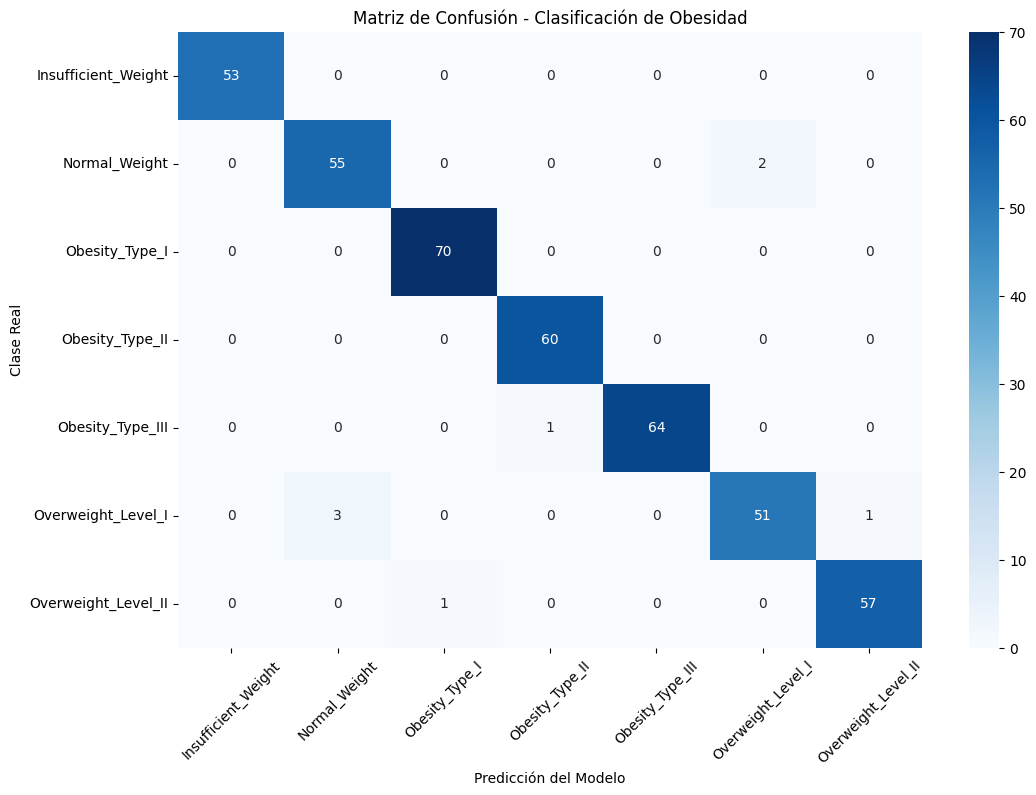

In [4]:
# 1. Calculamos la matriz de confusión
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels, labels=le.classes_)

# 2. Configuramos el gráfico
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('Matriz de Confusión - Clasificación de Obesidad')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.xticks(rotation=45)
plt.show()

# Análisis de Importancia de Características (Feature Importance)

En este apartado identificamos qué variables tienen mayor impacto en las predicciones del modelo.

* *Interpretación* : El hecho de que el Género aparezca como una de las variables más influyentes sugiere que existen patrones biométricos o de distribución de categorías muy diferenciados entre hombres y mujeres en este dataset (por ejemplo, ciertas categorías de obesidad pueden ser predominantes en un género específico).

* *Metodología* : Extraemos los pesos del modelo final (XGBClassifier) y los vinculamos con los nombres de las columnas generadas tras el preprocesamiento (incluyendo las variables expandidas por el One-Hot Encoder).

C:\Users\gemit\AppData\Local\Temp\ipykernel_14460\916202065.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')


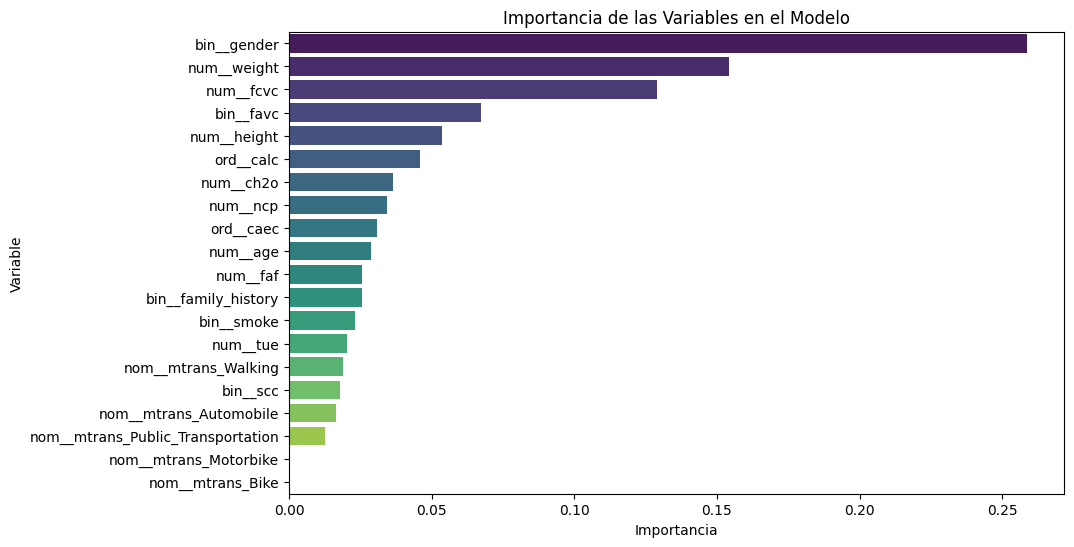

In [7]:

modelo_xgb = pipeline.named_steps['classifier']

#  Obtenemos los valores de importancia
importancias = modelo_xgb.feature_importances_

#  Recuperamos los nombres de las columnas que guardamos al cargar el modelo
nombres_columnas = pipeline.named_steps['preprocessor'].get_feature_names_out()

#Creamos un DataFrame para que sea fácil de graficar
df_importancias = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 4. Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')
plt.title('Importancia de las Variables en el Modelo')
plt.show()

# Análisis de Sesgo: Género vs. Categoría de Obesidad

Para validar la alta importancia que el modelo otorga al Género, realizamos un cruce de datos (crosstab). Esto nos permite verificar si ciertas categorías de obesidad están compuestas mayoritariamente por un solo género, lo que explicaría por qué el modelo utiliza esta variable como un "atajo" predictivo.

In [8]:
# 1. Cargamos el dataset original para tener la referencia completa
df_referencia = pd.read_csv("../data/raw/ObesityDataSet.csv")

# 2. Creamos la tabla de cruce (Crosstab)
tabla_genero = pd.crosstab(df_referencia['NObeyesdad'], df_referencia['Gender'])

# 3. Mostramos la tabla con un degradado de color para ver los "puntos calientes"
print("📊 Distribución de Género por Categoría:")
tabla_genero.style.background_gradient(cmap='Reds')

📊 Distribución de Género por Categoría:


Gender,Female,Male
NObeyesdad,,
Insufficient_Weight,173,99
Normal_Weight,141,146
Obesity_Type_I,156,195
Obesity_Type_II,2,295
Obesity_Type_III,323,1
Overweight_Level_I,145,145
Overweight_Level_II,103,187


# Análisis de Errores: Identificación de Fallos

En esta sección, filtramos los casos donde las predicciones del modelo no coinciden con las etiquetas reales. El objetivo es inspeccionar estos ejemplos "atípicos" para entender si el error se debe a ambigüedad en los datos o al sesgo detectado anteriormente (como hombres/mujeres en categorías inusuales).

In [12]:
# 1. Creamos un DataFrame con los resultados para comparar
analisis_errores = X_test.copy()
analisis_errores['Real'] = y_true_labels
analisis_errores['Prediccion'] = y_pred_labels

# 2. Filtramos los errores (donde Real no es igual a Prediccion)
errores = analisis_errores[analisis_errores['Real'] != analisis_errores['Prediccion']]

# 3. Mostramos los primeros 5 errores para analizar
print(f" El modelo cometió {len(errores)} errores de {len(y_true_labels)} casos.")
errores.head(10)

 El modelo cometió 8 errores de 418 casos.


,gender,age,height,weight,family_history,favc,fcvc,ncp,caec,smoke,ch2o,scc,faf,tue,calc,mtrans,Real,Prediccion
8,Male,18.000000,1.870000,173.000000,yes,yes,3.00000,3.00000,Frequently,no,2.000000,no,2.0,1.00000,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_II
67,Male,27.000000,1.930000,102.000000,yes,yes,2.00000,1.00000,Sometimes,no,1.000000,no,1.0,0.00000,Sometimes,Public_Transportation,Overweight_Level_II,Obesity_Type_I
149,Female,41.823567,1.721854,82.919584,no,yes,2.81646,3.36313,Sometimes,no,2.722063,no,3.0,0.26579,Sometimes,Automobile,Overweight_Level_I,Overweight_Level_II
154,Male,18.000000,1.650000,70.000000,yes,no,2.00000,3.00000,Sometimes,no,2.000000,no,0.0,0.00000,no,Public_Transportation,Overweight_Level_I,Normal_Weight
168,Female,21.000000,1.620000,69.000000,yes,yes,1.00000,3.00000,Frequently,no,2.000000,no,0.0,1.00000,no,Public_Transportation,Overweight_Level_I,Normal_Weight
285,Male,18.000000,1.800000,80.000000,yes,yes,2.00000,3.00000,Frequently,no,1.000000,no,0.0,1.00000,Frequently,Public_Transportation,Normal_Weight,Overweight_Level_I
361,Male,20.000000,1.810000,79.000000,yes,no,3.00000,1.00000,Sometimes,no,2.000000,no,0.0,0.00000,Sometimes,Public_Transportation,Normal_Weight,Overweight_Level_I
403,Male,20.000000,1.900000,91.000000,yes,yes,3.00000,4.00000,Sometimes,no,3.000000,no,2.0,0.00000,Sometimes,Walking,Overweight_Level_I,Normal_Weight


# Conclusiones del Análisis de Errores

Tras inspeccionar los fallos, confirmamos que el modelo presenta dificultades en casos que desafían las tendencias mayoritarias del dataset:

1. *Sesgo de Género:* El modelo tiende a clasificar erróneamente a hombres con obesidad extrema como Tipo II en lugar de Tipo III, debido a la bajísima representación de hombres en esta última categoría.

2. *Zonas de Frontera:* Errores entre Normal_Weight y Overweight_Level_I ocurren en individuos cuyos parámetros físicos están en el límite entre ambas clases, donde pequeñas variaciones de hábitos (FAF, TUE) confunden al algoritmo.

In [14]:
# 1. Calculamos el IMC para los casos donde el modelo falló
errores_con_imc = errores.copy()
errores_con_imc['IMC'] = errores_con_imc['weight'] / (errores_con_imc['height'] ** 2)

# 2. Mostramos las columnas clave para comparar
# Queremos ver si el IMC justifica la categoría Real o la Predicción
columnas_analisis = ['gender', 'weight', 'height', 'IMC', 'Real', 'Prediccion']
errores_con_imc[columnas_analisis].head(10)

,gender,weight,height,IMC,Real,Prediccion
8,Male,173.000000,1.870000,49.472390,Obesity_Type_III,Obesity_Type_II
67,Male,102.000000,1.930000,27.383285,Overweight_Level_II,Obesity_Type_I
149,Female,82.919584,1.721854,27.968197,Overweight_Level_I,Overweight_Level_II
154,Male,70.000000,1.650000,25.711662,Overweight_Level_I,Normal_Weight
168,Female,69.000000,1.620000,26.291724,Overweight_Level_I,Normal_Weight
285,Male,80.000000,1.800000,24.691358,Normal_Weight,Overweight_Level_I
361,Male,79.000000,1.810000,24.114038,Normal_Weight,Overweight_Level_I
403,Male,91.000000,1.900000,25.207756,Overweight_Level_I,Normal_Weight


# Informe de Diagnóstico: Sesgo de Género y Propuesta de IMC

Tras analizar los errores del modelo, se han extraído las siguientes conclusiones técnicas:
* *Identificación del Sesgo*: El modelo actual muestra una dependencia excesiva en la variable Gender. Esto se debe a un desequilibrio en el dataset original, donde ciertas categorías (como Obesity_Type_III) están compuestas casi exclusivamente por un solo género.

* *Impacto en la Fiabilidad*: El modelo tiende a ignorar valores de peso extremos en hombres (ej. 173 kg, IMC de 49.4) clasificándolos erróneamente en categorías inferiores solo por su género.

* *Solución Propuesta (Feature Engineering)*: Introducir el Índice de Masa Corporal (IMC) como variable de entrenamiento.
    * Fórmula: $IMC = \frac{Weight}{Height^2}$
 
    * Objetivo: Proporcionar al algoritmo una métrica física objetiva que unifique peso y altura, reduciendo la importancia relativa del género y mejorando la precisión en los casos "frontera".